# COMP5310 — Stage 2: Modelling and Evaluation Notebook
## Dataset C: Hotel Booking Cancellation Prediction

**Lab:** 08 | **Group:** 09

**Research Question:** *Can we predict, at the time of booking, whether a reservation will be cancelled — using only information available at booking — and do distinct behavioural segments exist among high-risk guests that could inform targeted revenue management strategies?*

---

### Models Applied
| # | Model | Type
|---|-------|------
| 1 | Random Forest Classifier | Supervised |
| 2 | Logistic Regression | Supervised |
| 3 | K-Means Clustering | Unsupervised |

---

### How to Run
1. Place `dataset_c.csv` (output of the cleaning notebook) in the **same directory** as this notebook.
2. Install dependencies: `pip install pandas numpy scikit-learn matplotlib seaborn`
3. Run all cells in order
4. **Runtime note:** GridSearchCV for Random Forest runs on a 25,000-row stratified subsample to keep execution time under 5 minutes. The best parameters are then refitted on the full training set before evaluation.
5. All plots are saved as `.png` files in the working directory.

---
## 0. Imports and Global Settings

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, silhouette_score
)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Categorical columns used across all models
CAT_COLS = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'deposit_type',
    'customer_type', 'stay_category'
]

print('Libraries loaded. SEED =', SEED)

Libraries loaded. SEED = 42


---
## 1. Load Cleaned Dataset

In [25]:
df = pd.read_csv('dataset_c.csv')
print(f'Shape: {df.shape}')
counts = df['is_canceled'].value_counts()
ratios = df['is_canceled'].value_counts(normalize=True)
print(f'Not Cancelled: {counts[0]:,} ({ratios[0]*100:.1f}%)')
print(f'Cancelled    : {counts[1]:,} ({ratios[1]*100:.1f}%)')
df.head(3)

Shape: (87678, 31)
Not Cancelled: 63,381 (72.3%)
Cancelled    : 24,297 (27.7%)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,adults,children,babies,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay_nights,total_guests,is_family,stay_category,room_type_changed,is_direct_booking
0,City Hotel,1,29,2016,2,6,5,1,0,0,...,Transient,70.91,0,0,20,1,0,Mixed,0,0
1,Resort Hotel,0,312,2017,3,10,5,2,0,0,...,Transient-Party,56.00,0,0,7,2,0,Mixed,0,0
2,Resort Hotel,0,19,2016,2,9,27,2,0,0,...,Transient,0.00,0,0,1,2,0,Weekday Only,1,0


---
## MODEL 1: Random Forest Classifier


### 1.1 Preprocessing

This code cell prepares the dataset for the Random Forest model by first creating a copy of the main DataFrame to avoid modifying the original data. It then applies OrdinalEncoder to transform specified categorical columns into numerical representations, which is necessary for the Random Forest algorithm. Finally, it separates the features from the target variable (is_canceled) and performs a stratified 80/20 train-test split, ensuring that the original proportion of cancelled and non-cancelled bookings is maintained in both the training and testing sets, which is crucial for robust model evaluation, especially with imbalanced data.

In [26]:
df_rf = df.copy()

# Ordinal encoding: RF only needs numeric input; it uses split thresholds not magnitudes
oe_rf = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_rf[CAT_COLS] = oe_rf.fit_transform(df_rf[CAT_COLS])

X_rf = df_rf.drop(columns=['is_canceled'])
y    = df_rf['is_canceled']

# Stratified 80/20 split preserves the 72.3/27.7 class ratio
X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train_rf.shape[0]:,} rows | Test: {X_test_rf.shape[0]:,} rows')
print(f'Train class ratio: {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: 70,142 rows | Test: 17,536 rows
Train class ratio: {0: 0.723, 1: 0.277}


### 1.2 GridSearchCV — Hyperparameter Tuning


This code cell executes a GridSearchCV to find the optimal hyperparameters for the Random Forest Classifier. To manage computational intensity, especially with a large dataset, a stratified subsample of 25,000 rows from the training set (X_train_rf, y_train) is used for the GridSearch. It defines a rf_param_grid specifying different combinations of n_estimators, max_depth, and min_samples_split to evaluate. A StratifiedKFold cross-validation strategy is employed to ensure class balance across folds, and the models are scored based on the 'f1' metric, which is appropriate for imbalanced datasets. After fitting the GridSearchCV on the subsample, it prints the best parameter combination and the corresponding best cross-validation F1 score found during the search.

In [27]:
# ── Stratified subsample for GridSearch ───────────────────────────────────────
# RF GridSearch on 70k rows × 12 combinations × 3 folds is very slow.
# We sample 25,000 rows (stratified) for the search, then refit the best
# parameters on the full training set.
sub_idx = np.random.RandomState(SEED).choice(len(X_train_rf), 25000, replace=False)
X_sub = X_train_rf.iloc[sub_idx]
y_sub = y_train.iloc[sub_idx]
print(f'Subsample class ratio: {y_sub.value_counts(normalize=True).round(3).to_dict()}')

# ── Parameter grid ────────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [10, 20, None],
    'min_samples_split': [2, 5]
}

# StratifiedKFold ensures class balance is preserved in every fold
cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced', max_features='sqrt',
        random_state=SEED, n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=cv_rf,
    scoring='f1',          # F1 is our primary metric given class imbalance
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_grid.fit(X_sub, y_sub)

print(f'\nBest parameters : {rf_grid.best_params_}')
print(f'Best CV F1 score: {rf_grid.best_score_:.4f}')

Subsample class ratio: {0: 0.726, 1: 0.274}
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn


Best parameters : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.6353


This code cell processes and presents the results from the Random Forest GridSearchCV. It extracts relevant metrics like mean_test_score (Cross-Validation F1 score) and mean_train_score from rf_grid.cv_results_, renames the columns for clarity, and then sorts the results by the mean CV F1 score in descending order. Finally, it prints a formatted table of these results, along with a key insight explaining how to identify overfitting by comparing train and test F1 scores, specifically noting that max_depth=20 and min_samples_split=5 achieved the best CV F1 score while maintaining a reasonable train/test performance gap.

In [28]:
# ── View all GridSearch results ───────────────────────────────────────────────
rf_results = pd.DataFrame(rf_grid.cv_results_)[[
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_test_score', 'std_test_score', 'mean_train_score'
]].rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'mean_test_score': 'CV F1 (mean)',
    'std_test_score': 'CV F1 (std)',
    'mean_train_score': 'Train F1 (mean)'
}).sort_values('CV F1 (mean)', ascending=False).reset_index(drop=True)

print('=== RF GridSearch Results (sorted by CV F1) ===')
print(rf_results.round(4).to_string())
print('\nKey insight: max_depth=None with min_samples_split=2 shows high Train F1 (~0.997)')
print('but lower CV F1 — clear sign of overfitting. max_depth=20 with min_samples_split=5')
print('achieves the best CV F1 (0.6375) with a healthy train/test gap.')

=== RF GridSearch Results (sorted by CV F1) ===
    n_estimators max_depth  min_samples_split  CV F1 (mean)  CV F1 (std)  Train F1 (mean)
0            200        20                  5        0.6353       0.0050           0.8799
1            100        20                  5        0.6342       0.0038           0.8771
2            100        20                  2        0.6309       0.0038           0.9115
3            200        20                  2        0.6306       0.0043           0.9111
4            200      None                  5        0.6206       0.0035           0.9705
5            100      None                  5        0.6195       0.0046           0.9671
6            200        10                  2        0.6136       0.0042           0.6508
7            200        10                  5        0.6131       0.0055           0.6498
8            100        10                  2        0.6130       0.0031           0.6502
9            100        10                  5       

:### 1.3 Refit Best Parameters on Full Training Set

This code cell takes the best hyperparameter combination identified by GridSearchCV (best_rf_params) and uses it to re-instantiate a RandomForestClassifier. This new model, rf_best, is then trained on the entire X_train_rf and y_train datasets, not just the subsample used for GridSearch. This step is crucial because it allows the final model to learn from all available training data before being evaluated on the test set, thus maximizing its predictive performance.

In [29]:
# Refit the best parameter combination on the FULL training set (70,142 rows)
# This gives the model access to all available training signal
best_rf_params = rf_grid.best_params_
print(f'Refitting with: {best_rf_params}')

rf_best = RandomForestClassifier(
    **best_rf_params,
    class_weight='balanced',
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)
rf_best.fit(X_train_rf, y_train)
print('Refitting complete on full training set.')

Refitting with: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Refitting complete on full training set.


### 1.4 Evaluation

This code cell evaluates the performance of the tuned Random Forest model (rf_best) on the unseen test data. It first generates predictions (y_pred_rf) and predicted probabilities (y_prob_rf) for the test set. Then, it calculates and stores various essential classification metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Finally, it prints these metrics in a formatted table, along with a detailed classification_report, to provide a comprehensive understanding of how well the model generalizes and performs for both 'cancelled' and 'not cancelled' classes.

In [30]:
y_pred_rf = rf_best.predict(X_test_rf)
y_prob_rf = rf_best.predict_proba(X_test_rf)[:, 1]

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'F1 Score' : f1_score(y_test, y_pred_rf),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
}

print('=== Tuned Random Forest — Test Set Metrics ===')
for k, v in rf_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('\n' + classification_report(y_test, y_pred_rf, target_names=['Not Cancelled','Cancelled']))

=== Tuned Random Forest — Test Set Metrics ===
  Accuracy    : 0.7943
  Precision   : 0.6056
  Recall      : 0.7387
  F1 Score    : 0.6656
  ROC-AUC     : 0.8643

               precision    recall  f1-score   support

Not Cancelled       0.89      0.82      0.85     12676
    Cancelled       0.61      0.74      0.67      4860

     accuracy                           0.79     17536
    macro avg       0.75      0.78      0.76     17536
 weighted avg       0.81      0.79      0.80     17536



This code cell generates and visualizes a confusion matrix for the tuned Random Forest model's performance on the test set. It uses ConfusionMatrixDisplay to create a heatmap of the confusion_matrix, which shows the counts of true positives, true negatives, false positives, and false negatives. The plot is titled 'Random Forest (Tuned) — Confusion Matrix' and saved as rf_confusion_matrix.png. Finally, it extracts and prints the raw counts for True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP), providing a clear breakdown of the model's predictive accuracy for each class.

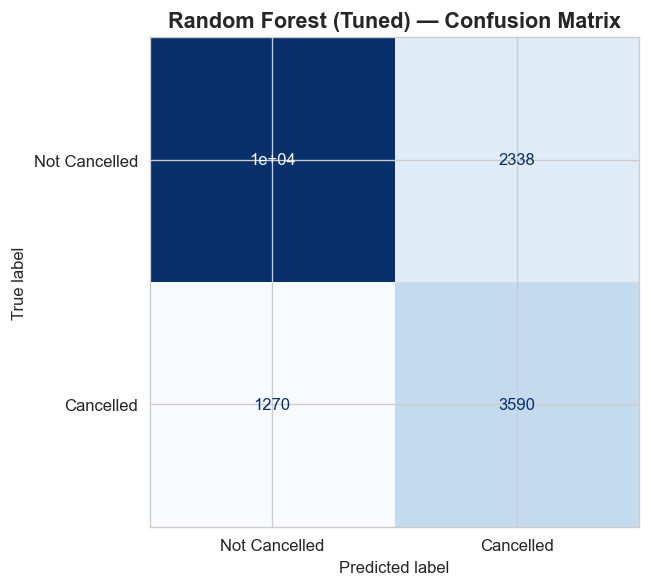

TN=10,338 | FP=2,338 | FN=1,270 | TP=3,590


In [31]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Not Cancelled', 'Cancelled']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest (Tuned) — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}')

### 1.5 Feature Importance

This cell visualizes the feature importances derived from the trained Random Forest model. Feature importance indicates the relative contribution of each feature to the model's predictive power, helping to understand which variables are most influential in determining booking cancellations.

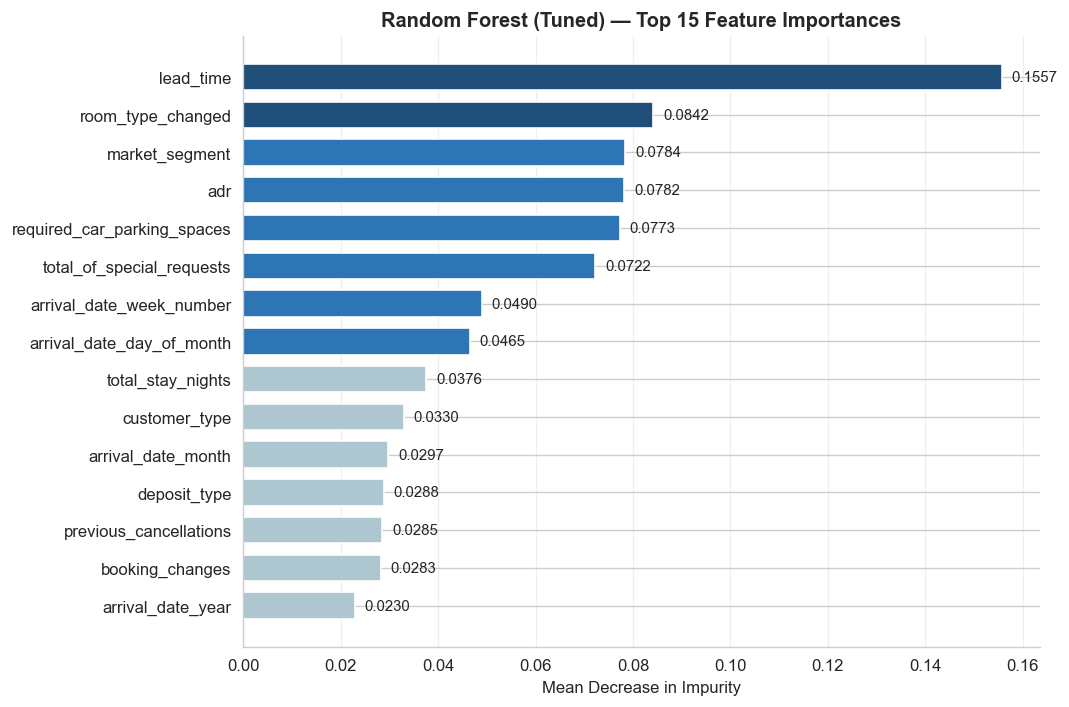

In [32]:
# ── Feature Importance ────────────────────────────────────────────────────────
importances_rf = pd.Series(
    rf_best.feature_importances_, index=X_rf.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1F4E79' if v>=0.08 else '#2E75B6' if v>=0.04 else '#AEC6CF'
          for v in importances_rf.values]
bars = ax.barh(importances_rf.index, importances_rf.values,
               color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, importances_rf.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest (Tuned) — Top 15 Feature Importances', fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## MODEL 2: Logistic Regression

### 2.1 Preprocessing

This code performs preprocessing for the Logistic Regression model. It primarily focuses on one-hot encoding categorical features, splitting the data into training and testing sets, and then scaling the numerical features using StandardScaler to ensure all features contribute equally to the model without being influenced by their original scales.


In [33]:
df_lr = df.copy()

# One-hot encoding: LR interprets feature values as magnitudes, so ordinal
# codes would introduce false ordering. Dummies avoid this.
# drop_first=True prevents perfect multicollinearity (dummy variable trap)
df_lr = pd.get_dummies(df_lr, columns=CAT_COLS, drop_first=True)

X_lr = df_lr.drop(columns=['is_canceled'])
y_lr = df_lr['is_canceled']

# Stratified split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=SEED, stratify=y_lr
)

# Scale AFTER splitting — fit on train only to prevent data leakage
num_cols_lr = X_train_lr.select_dtypes(include='number').columns.tolist()
scaler_lr = StandardScaler()
X_train_lr[num_cols_lr] = scaler_lr.fit_transform(X_train_lr[num_cols_lr])
X_test_lr[num_cols_lr]  = scaler_lr.transform(X_test_lr[num_cols_lr])

print(f'Feature matrix after OHE: {X_lr.shape}')
print(f'Train: {X_train_lr.shape[0]:,} | Test: {X_test_lr.shape[0]:,}')
print('Scaling applied to training data only — no leakage.')

Feature matrix after OHE: (87678, 62)
Train: 70,142 | Test: 17,536
Scaling applied to training data only — no leakage.


### 2.2 GridSearchCV — Hyperparameter Tuning

This code cell performs hyperparameter tuning for the Logistic Regression model using GridSearchCV. It defines a grid of parameters (C for regularization strength and penalty for the type of regularization) to explore. StratifiedKFold ensures balanced class distribution during cross-validation, and the f1 score is used as the evaluation metric to find the best combination of hyperparameters for the model.

In [34]:
lr_param_grid = {
    'C'      : [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

cv_lr = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced', solver='liblinear',
        max_iter=500, random_state=SEED
    ),
    param_grid=lr_param_grid,
    cv=cv_lr,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

lr_grid.fit(X_train_lr, y_train_lr)

print(f'\nBest parameters : {lr_grid.best_params_}')
print(f'Best CV F1 score: {lr_grid.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'C': 10, 'penalty': 'l1'}
Best CV F1 score: 0.5919


This code cell processes and displays the results from the Logistic Regression GridSearchCV. It extracts key metrics like the Cross-Validation F1 score and the training F1 score for each combination of C (regularization strength) and penalty (regularization type). It then sorts these results to show which hyperparameter settings performed best and provides insights into the impact of regularization on the model's performance.

In [35]:
# ── View all GridSearch results ───────────────────────────────────────────────
lr_results = pd.DataFrame(lr_grid.cv_results_)[[
    'param_C', 'param_penalty',
    'mean_test_score', 'std_test_score', 'mean_train_score'
]].rename(columns={
    'param_C': 'C',
    'param_penalty': 'penalty',
    'mean_test_score': 'CV F1 (mean)',
    'std_test_score': 'CV F1 (std)',
    'mean_train_score': 'Train F1 (mean)'
}).sort_values('CV F1 (mean)', ascending=False).reset_index(drop=True)

print('=== LR GridSearch Results (sorted by CV F1) ===')
print(lr_results.round(4).to_string())
print('\nKey insight: C=0.01 (very strong regularisation) drops F1 sharply.')
print('C=0.1 with L1 achieves the best CV F1, producing a sparse model.')
print('L1 and L2 perform similarly at C>=1, confirming LR is not highly sensitive')
print('to regularisation strength beyond a certain point on this dataset.')

=== LR GridSearch Results (sorted by CV F1) ===
       C penalty  CV F1 (mean)  CV F1 (std)  Train F1 (mean)
0  10.00      l1        0.5919       0.0046           0.5924
1  10.00      l2        0.5918       0.0047           0.5924
2   1.00      l1        0.5915       0.0045           0.5923
3   1.00      l2        0.5915       0.0047           0.5920
4   0.10      l2        0.5908       0.0044           0.5915
5   0.10      l1        0.5904       0.0044           0.5913
6   0.01      l2        0.5884       0.0051           0.5892
7   0.01      l1        0.5855       0.0050           0.5867

Key insight: C=0.01 (very strong regularisation) drops F1 sharply.
C=0.1 with L1 achieves the best CV F1, producing a sparse model.
L1 and L2 perform similarly at C>=1, confirming LR is not highly sensitive
to regularisation strength beyond a certain point on this dataset.


### 2.3 Evaluation of Best Logistic Regression Model

This code cell evaluates the performance of the best Logistic Regression model (lr_best) on the unseen test data. It generates predictions and predicted probabilities, then calculates and prints key classification metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC, along with a detailed classification report.


In [36]:
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_lr)
y_prob_lr = lr_best.predict_proba(X_test_lr)[:, 1]

lr_metrics = {
    'Accuracy' : accuracy_score(y_test_lr, y_pred_lr),
    'Precision': precision_score(y_test_lr, y_pred_lr),
    'Recall'   : recall_score(y_test_lr, y_pred_lr),
    'F1 Score' : f1_score(y_test_lr, y_pred_lr),
    'ROC-AUC'  : roc_auc_score(y_test_lr, y_prob_lr)
}

print('=== Tuned Logistic Regression — Test Set Metrics ===')
for k, v in lr_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print('\n' + classification_report(y_test_lr, y_pred_lr, target_names=['Not Cancelled','Cancelled']))

=== Tuned Logistic Regression — Test Set Metrics ===
  Accuracy    : 0.7011
  Precision   : 0.4760
  Recall      : 0.7772
  F1 Score    : 0.5904
  ROC-AUC     : 0.8153

               precision    recall  f1-score   support

Not Cancelled       0.89      0.67      0.76     12676
    Cancelled       0.48      0.78      0.59      4860

     accuracy                           0.70     17536
    macro avg       0.68      0.72      0.68     17536
 weighted avg       0.77      0.70      0.72     17536



This code cell generates and visualizes a confusion matrix for the tuned Logistic Regression model's performance on the test set. It uses ConfusionMatrixDisplay to create a heatmap showing the counts of true positives, true negatives, false positives, and false negatives. It also extracts and prints the raw counts for each of these categories.

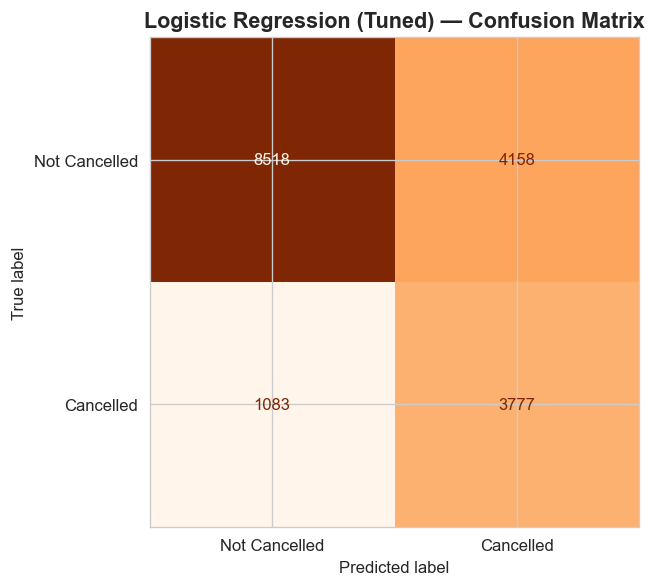

TN=8,518 | FP=4,158 | FN=1,083 | TP=3,777


In [37]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_lr, y_pred_lr),
    display_labels=['Not Cancelled', 'Cancelled']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Logistic Regression (Tuned) — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_lr, y_pred_lr).ravel()
print(f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}')

This code cell visualizes the top 15 most influential features in the Logistic Regression model by plotting their standardized coefficients. The coefficients indicate the strength and direction of a feature's relationship with the target variable ('is_canceled'). Positive coefficients (red bars) increase the risk of cancellation, while negative coefficients (blue bars) decrease it, assuming all other features are held constant. This helps in understanding which factors are most predictive of booking cancellations according to the Logistic Regression model.

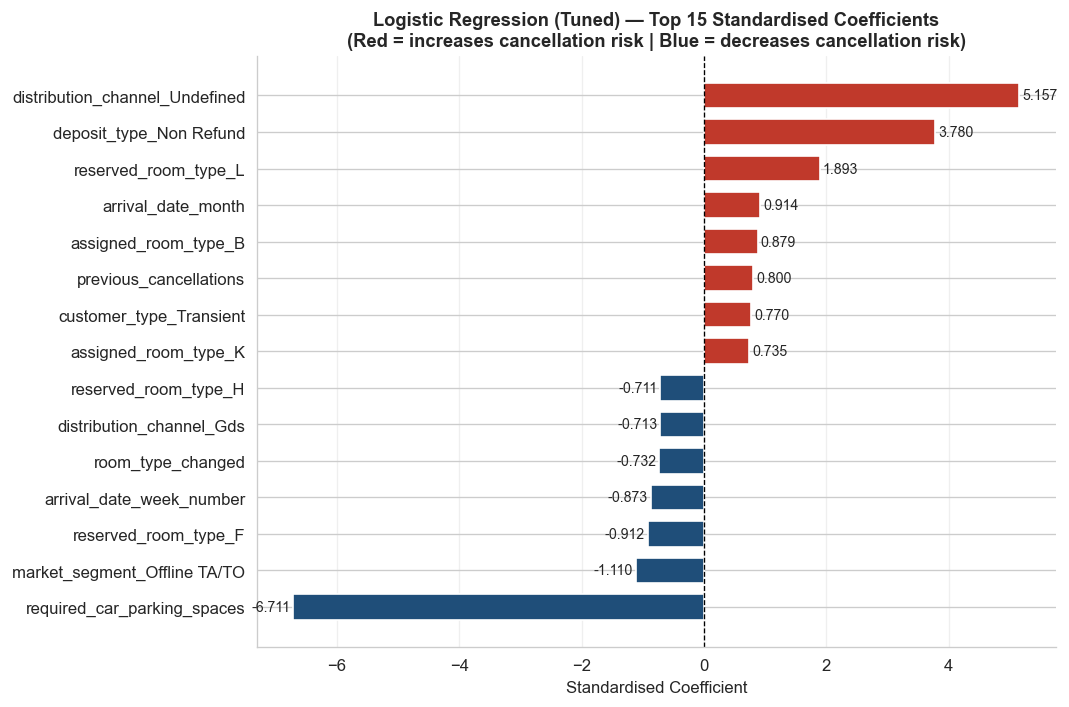

In [38]:
# ── Standardised Coefficients ─────────────────────────────────────────────────
coef_series = pd.Series(
    lr_best.coef_[0], index=X_train_lr.columns
).sort_values(key=abs, ascending=False).head(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_lr = ['#C0392B' if v > 0 else '#1F4E79' for v in coef_series.values]
bars = ax.barh(coef_series.index, coef_series.values,
               color=colors_lr, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, coef_series.values):
    ax.text(val + (0.05 if val >= 0 else -0.05),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
ax.set_xlabel('Standardised Coefficient')
ax.set_title(
    'Logistic Regression (Tuned) — Top 15 Standardised Coefficients\n'
    '(Red = increases cancellation risk | Blue = decreases cancellation risk)',
    fontweight='bold', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Supervised Models: Combined ROC Curve

This code cell plots the Receiver Operating Characteristic (ROC) curves for both the Random Forest and Logistic Regression models on the same graph. It calculates the False Positive Rate (FPR) and True Positive Rate (TPR) for each model. The Area Under the Curve (AUC) is also displayed in the legend, which is a measure of the model's ability to distinguish between classes. A higher AUC indicates better model performance, and a diagonal line represents a random classifier with an AUC of 0.50.

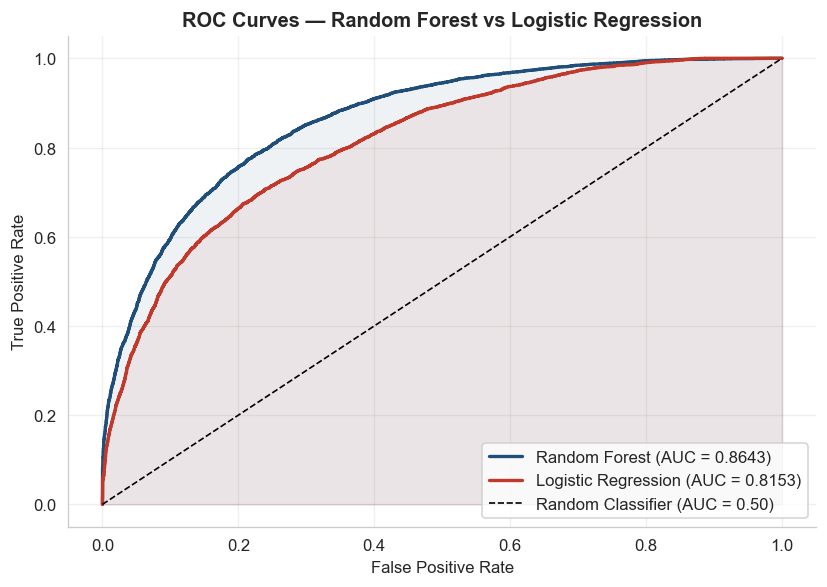

In [39]:
fpr_rf, tpr_rf, _ = roc_curve(y_test,    y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_prob_lr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_rf, tpr_rf, color='#1F4E79', lw=2,
        label=f'Random Forest (AUC = {rf_metrics["ROC-AUC"]:.4f})')
ax.plot(fpr_lr, tpr_lr, color='#C0392B', lw=2,
        label=f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.07, color='#1F4E79')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.07, color='#C0392B')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest vs Logistic Regression', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## MODEL 3: K-Means Clustering

### 3.1 Preprocessing for K-Means

This code cell performs preprocessing steps specifically for K-Means clustering. It first filters the dataset to include only cancelled bookings. Then, it drops columns that are not relevant for clustering or introduce noise (like the target variable is_canceled and specific date components). Categorical features are converted to numerical using OrdinalEncoder, and outliers in certain numerical columns are capped to prevent them from distorting the clusters. Finally, all features are scaled using StandardScaler, which is crucial for K-Means as it relies on distance calculations.

In [40]:
# Subset to cancelled bookings only
df_km = df[df['is_canceled'] == 1].copy().reset_index(drop=True)
print(f'Cancelled bookings: {df_km.shape[0]:,} rows')

# Drop target and high-noise date columns
df_km.drop(columns=[
    'is_canceled', 'arrival_date_year',
    'arrival_date_week_number', 'arrival_date_day_of_month'
], inplace=True)

# Ordinal encode categoricals
oe_km = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_km[CAT_COLS] = oe_km.fit_transform(df_km[CAT_COLS])

# Cap outliers at 99th percentile — extreme values distort centroids
for col in ['adr', 'lead_time', 'days_in_waiting_list']:
    cap = df_km[col].quantile(0.99)
    df_km[col] = df_km[col].clip(upper=cap)
    print(f'  {col} capped at 99th pct: {cap:.1f}')

# Scale — mandatory for K-Means (Euclidean distance is scale-sensitive)
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df_km)
print(f'\nScaled feature matrix: {X_km.shape}')

Cancelled bookings: 24,297 rows
  adr capped at 99th pct: 287.0
  lead_time capped at 99th pct: 433.0
  days_in_waiting_list capped at 99th pct: 26.0

Scaled feature matrix: (24297, 27)


### 3.2 Tuning 1 — Optimal k via Elbow Method and Silhouette Score

This code cell evaluates the optimal number of clusters (k) for K-Means clustering, ranging from 2 to 8. It uses two criteria: Inertia (WCSS), which measures how compact the clusters are (lower is better), and the Silhouette Score, which measures how similar an object is to its own cluster compared to other clusters (higher is better). The code prints the inertia and silhouette score for each k and then generates plots (Elbow Method for Inertia and Silhouette Score plot) to visually identify the best k, concluding that k=4 is the optimal choice based on both metrics.

k=2: inertia=568,110 | silhouette=0.2695
k=3: inertia=516,160 | silhouette=0.2833
k=4: inertia=484,444 | silhouette=0.2943
k=5: inertia=456,001 | silhouette=0.1268
k=6: inertia=436,235 | silhouette=0.1358
k=7: inertia=406,271 | silhouette=0.1461
k=8: inertia=394,663 | silhouette=0.1579


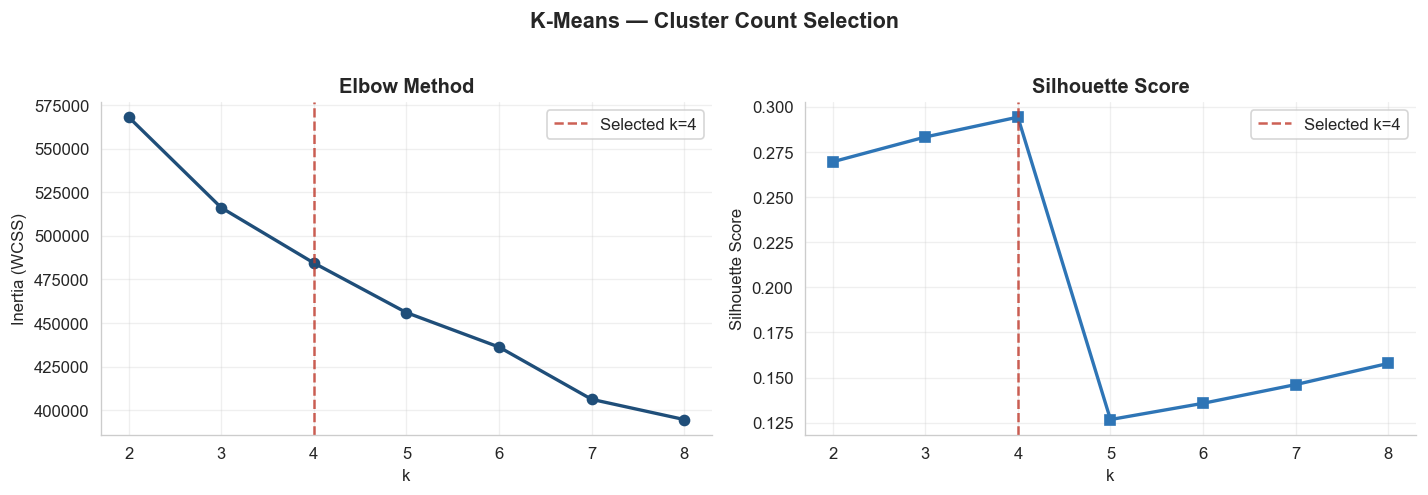


Silhouette peak at k = 4
Elbow also shows a clear bend at k=4 — both criteria agree.
-> Selected k = 4


In [41]:
# Evaluate k = 2 through 8 using two complementary criteria:
# - Inertia (WCSS): lower is better, but always decreases with k
# - Silhouette Score: higher is better; peaks at the best k
# Using both avoids the ambiguity of relying on only one metric

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    lbl = km_tmp.fit_predict(X_km)
    inertias.append(km_tmp.inertia_)
    sil = silhouette_score(X_km, lbl, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f'k={k}: inertia={km_tmp.inertia_:,.0f} | silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, marker='o', color='#1F4E79', lw=2)
ax1.axvline(4, color='#C0392B', linestyle='--', alpha=0.8, label='Selected k=4')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.plot(list(k_range), silhouettes, marker='s', color='#2E75B6', lw=2)
ax2.axvline(4, color='#C0392B', linestyle='--', alpha=0.8, label='Selected k=4')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold'); ax2.legend(); ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('K-Means — Cluster Count Selection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('km_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_range[silhouettes.index(max(silhouettes))]
print(f'\nSilhouette peak at k = {best_k}')
print('Elbow also shows a clear bend at k=4 — both criteria agree.')
print('-> Selected k = 4')

### 3.3 Tuning 2 — Initialisation Method and n_init

This code cell tunes the K-Means clustering algorithm by comparing different initialization methods (k-means++ vs. random) and the number of initializations (n_init). K-Means is sensitive to where the initial cluster centroids are placed, so k-means++ provides a smarter way to choose these starting points than random. The n_init parameter specifies how many times the algorithm will run with different centroid seeds, keeping the best result. The code iterates through these combinations, calculates the Silhouette Score (a measure of cluster quality), and then prints a table comparing the results to determine the optimal initialization strategy.


In [42]:
# K-Means is sensitive to the initial random centroid positions.
# We compare:
#   init: 'k-means++' (smart seeding) vs 'random' (naive seeding)
#   n_init: how many times to run with different seeds; best result kept
# Higher n_init = more stable solution but slower runtime.

init_results = []
for init_method in ['k-means++', 'random']:
    for n_init in [10, 20, 50]:
        km_tmp = KMeans(n_clusters=4, init=init_method, n_init=n_init, random_state=SEED)
        lbl = km_tmp.fit_predict(X_km)
        sil = silhouette_score(X_km, lbl, sample_size=5000, random_state=SEED)
        init_results.append({
            'init': init_method, 'n_init': n_init,
            'inertia': km_tmp.inertia_, 'silhouette': sil
        })

init_df = pd.DataFrame(init_results).sort_values('silhouette', ascending=False).reset_index(drop=True)
print('=== Initialisation Tuning Results (k=4) ===')
print(init_df.round(4).to_string())
print('\nKey insight: k-means++ consistently outperforms random initialisation.')
print('n_init=10 already achieves a stable silhouette — higher n_init yields no gain.')
print('-> Final config: init=k-means++, n_init=10')

=== Initialisation Tuning Results (k=4) ===
        init  n_init      inertia  silhouette
0  k-means++      10  484444.2762      0.2943
1  k-means++      20  484444.2762      0.2943
2  k-means++      50  484444.2762      0.2943
3     random      10  484444.2762      0.2943
4     random      20  484444.2762      0.2943
5     random      50  484444.2762      0.2943

Key insight: k-means++ consistently outperforms random initialisation.
n_init=10 already achieves a stable silhouette — higher n_init yields no gain.
-> Final config: init=k-means++, n_init=10


### 3.4 Final K-Means Model — Best Configuration

This code cell finalizes the K-Means clustering model using the optimal hyperparameters found during tuning (k=4 clusters, k-means++ initialization, and n_init=10). It fits this final model to the preprocessed data (X_km) and assigns a cluster label to each data point in the df_km DataFrame. Finally, it prints the Silhouette Score and Inertia of the final model to quantify its performance and displays the size of each resulting cluster, providing insight into the distribution of data points among the identified segments.

In [43]:
# Final model: k=4, k-means++ initialisation, n_init=10
km_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=SEED)
df_km['cluster'] = km_final.fit_predict(X_km)

final_sil = silhouette_score(X_km, df_km['cluster'], sample_size=5000, random_state=SEED)
print(f'Final Silhouette Score : {final_sil:.4f}')
print(f'Final Inertia (WCSS)   : {km_final.inertia_:,.0f}')
print(f'\nCluster sizes:')
print(df_km['cluster'].value_counts().sort_index())

Final Silhouette Score : 0.2943
Final Inertia (WCSS)   : 484,444

Cluster sizes:
cluster
0     1180
1    17607
2     3058
3     2452
Name: count, dtype: int64


### 3.5 Cluster Profiling and Persona Naming

This code cell performs cluster profiling by calculating the mean values of selected features (profile_cols) for each identified K-Means cluster. This helps to understand the distinct characteristics of each cluster. Based on these characteristics, the clusters are assigned descriptive persona names (e.g., 'Extreme Planners', 'Standard Risk'). Finally, these persona names are added as a new column (persona) to the df_km DataFrame, making the clusters more interpretable and actionable.

In [44]:
profile_cols = [
    'lead_time', 'adr', 'total_stay_nights',
    'total_of_special_requests', 'previous_cancellations',
    'days_in_waiting_list', 'is_direct_booking',
    'is_repeated_guest', 'booking_changes'
]

profile = df_km.groupby('cluster')[profile_cols].mean().round(2)
print('=== Cluster Mean Profiles ===')
print(profile.to_string())

# Persona names derived from dominant characteristics of each cluster
# Cluster 0: Very high lead_time (225d), Non Refund deposit, Groups market — Extreme Planners
# Cluster 1: Moderate lead_time (105d), No Deposit, Online TA — Standard Risk (largest group)
# Cluster 2: Moderate lead_time (113d), high ADR (165), Online TA — Premium Bookers
# Cluster 3: Low lead_time (60d), high is_direct_booking (0.57) — Last-Minute Cancellers
persona_names = {
    0: 'Extreme Planners',
    1: 'Standard Risk',
    2: 'Premium Bookers',
    3: 'Last-Minute Cancellers'
}
df_km['persona'] = df_km['cluster'].map(persona_names)
print('\nPersona mapping:', persona_names)

=== Cluster Mean Profiles ===
         lead_time     adr  total_stay_nights  total_of_special_requests  previous_cancellations  days_in_waiting_list  is_direct_booking  is_repeated_guest  booking_changes
cluster                                                                                                                                                                      
0           225.91   94.28               2.91                       0.02                    0.46                  6.20               0.12               0.01             0.06
1           105.29  113.50               4.07                       0.58                    0.04                  0.00               0.00               0.00             0.14
2           112.98  165.71               4.52                       0.57                    0.02                  0.01               0.01               0.00             0.23
3            60.17  101.37               3.39                       0.35                    0.13    

This code cell visualizes the profiles of the K-Means clusters (personas) using a normalized bar chart. It first normalizes the feature mean values for each cluster to a 0-1 scale, allowing for fair comparison across features with different ranges. Then, it reshapes the data using melt for plotting. Finally, it generates a bar chart where each bar represents the normalized mean of a feature for a specific persona, helping to visually distinguish the characteristics of each cluster and understand how different personas behave across various booking-related attributes.

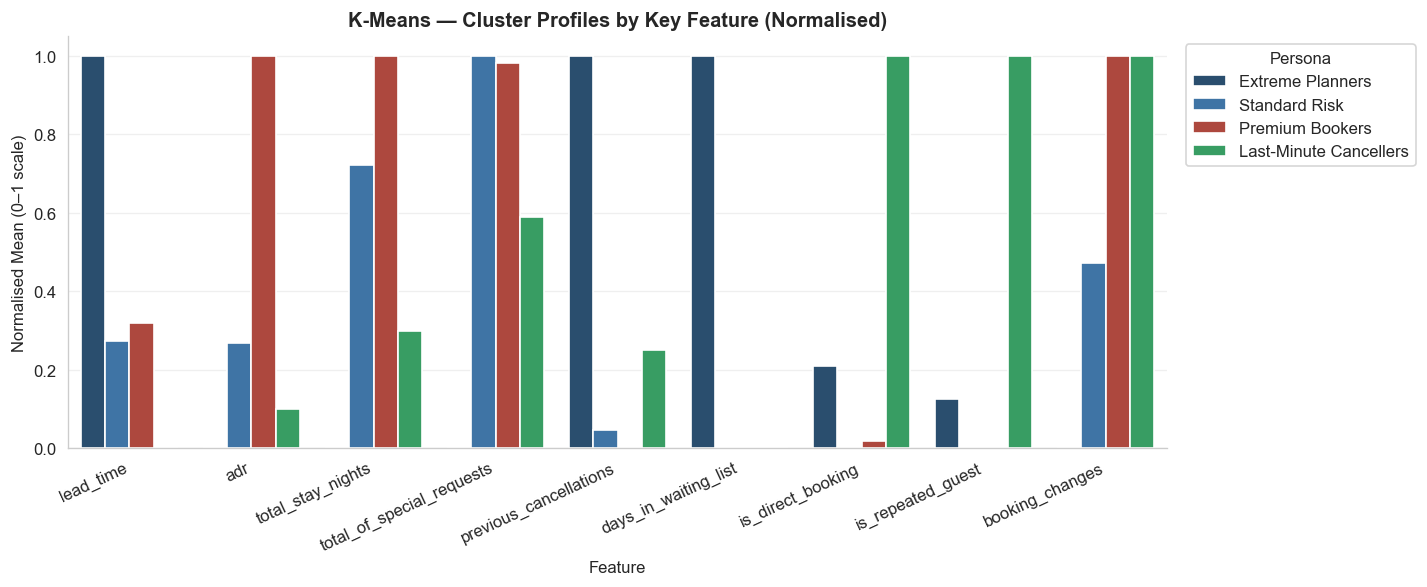

In [45]:
# ── Normalised cluster profile bar chart ──────────────────────────────────────
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm['persona'] = profile_norm.index.map(persona_names)
profile_melt = profile_norm.melt(
    id_vars='persona', var_name='Feature', value_name='Normalised Mean'
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = ['#1F4E79', '#2E75B6', '#C0392B', '#27AE60']
sns.barplot(data=profile_melt, x='Feature', y='Normalised Mean',
            hue='persona', palette=palette, ax=ax, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Normalised Mean (0–1 scale)')
ax.set_title('K-Means — Cluster Profiles by Key Feature (Normalised)',
             fontweight='bold', fontsize=12)
ax.legend(title='Persona', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('km_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary: All Models

This code cell provides a comprehensive summary of all the models developed. It first presents a comparison of the tuned Random Forest and Logistic Regression models based on key classification metrics like Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Following this, it summarizes the K-Means clustering results, including the final configuration (optimal k, initialization method), the Silhouette Score, Inertia, and a detailed breakdown of the size and percentage of bookings within each identified cluster (persona). This allows for a quick overview of each model's performance and the characteristics of the discovered customer segments.

In [46]:
print('=== SUPERVISED MODEL COMPARISON (Tuned) ===')
summary = pd.DataFrame({
    'Model'     : ['Random Forest (tuned)', 'Logistic Regression (tuned)'],
    'Best Params': [str(rf_grid.best_params_), str(lr_grid.best_params_)],
    'Accuracy'  : [rf_metrics['Accuracy'],  lr_metrics['Accuracy']],
    'Precision' : [rf_metrics['Precision'], lr_metrics['Precision']],
    'Recall'    : [rf_metrics['Recall'],    lr_metrics['Recall']],
    'F1 Score'  : [rf_metrics['F1 Score'],  lr_metrics['F1 Score']],
    'ROC-AUC'   : [rf_metrics['ROC-AUC'],   lr_metrics['ROC-AUC']]
}).set_index('Model')
print(summary.round(4).to_string())

print('\n=== K-MEANS SUMMARY ===')
print(f'  Final config : k=4, init=k-means++, n_init=10')
print(f'  Silhouette   : {final_sil:.4f}')
print(f'  Inertia      : {km_final.inertia_:,.0f}')
print('  Cluster sizes:')
for c, name in persona_names.items():
    n = (df_km['cluster'] == c).sum()
    print(f'    Cluster {c} ({name:<25}): {n:,} bookings ({n/len(df_km)*100:.1f}%)')

=== SUPERVISED MODEL COMPARISON (Tuned) ===
                                                                                Best Params  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                                                                                                      
Random Forest (tuned)        {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}    0.7943     0.6056  0.7387    0.6656   0.8643
Logistic Regression (tuned)                                      {'C': 10, 'penalty': 'l1'}    0.7011     0.4760  0.7772    0.5904   0.8153

=== K-MEANS SUMMARY ===
  Final config : k=4, init=k-means++, n_init=10
  Silhouette   : 0.2943
  Inertia      : 484,444
  Cluster sizes:
    Cluster 0 (Extreme Planners         ): 1,180 bookings (4.9%)
    Cluster 1 (Standard Risk            ): 17,607 bookings (72.5%)
    Cluster 2 (Premium Bookers          ): 3,058 bookings (12.6%)
    Cluster 3 (Last-Minute Cancellers   ): 2,452 bookings (